In [1]:
!git clone https://github.com/ultralytics/yolov5.git


Cloning into 'yolov5'...
remote: Enumerating objects: 17265, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 17265 (delta 107), reused 60 (delta 60), pack-reused 17079 (from 2)
Receiving objects: 100% (17265/17265), 15.92 MiB | 12.52 MiB/s, done.
Resolving deltas: 100% (11808/11808), done.


In [2]:
%cd yolov5

/kaggle/working/yolov5


In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 911.6/911.6 kB 23.7 MB/s eta 0:00:0000:01


In [4]:
import os
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from tqdm import tqdm
import tensorflow as tf
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, AveragePooling2D, Flatten, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
categories = {'Others': 0, 'Honda': 1, 'Mazda': 2, 'Mitsubishi': 3, 'Suzuki': 4, 'Toyota': 5, 'Hyundai': 6, 'KIA': 7, 'VinFast': 8}
data_path = '/kaggle/input/car-brand/Public/Public'
num_class = 9

In [2]:
csv_file = "/kaggle/input/car-brand/CarDataset.csv"

# Đọc file CSV
df = pd.read_csv(csv_file, header=None)
df.columns = ['ImagePath', 'CategoryID']  # Đặt tên cột

# Đếm số lượng ảnh trong mỗi class
class_counts = df['CategoryID'].value_counts()

# In kết quả
print("Số lượng ảnh trong mỗi class:")
for class_id, count in class_counts.items():
    print(f"Class {class_id}: {count} ảnh")

# Tổng số ảnh
total_images = len(df)
print(f"Tổng số ảnh: {total_images}")

Số lượng ảnh trong mỗi class:
Class 4: 6551 ảnh
Class 5: 5768 ảnh
Class 0: 4543 ảnh
Class 6: 3414 ảnh
Class 7: 3177 ảnh
Class 2: 3155 ảnh
Class 1: 3117 ảnh
Class 3: 2827 ảnh
Class 8: 2739 ảnh
Tổng số ảnh: 35291


# Dataset Visualization

In [6]:
def create_image_collage(csv_file, data_path, num_imgs_per_row=10, img_size=(150, 150)):
    reverse_categories = {v: k for k, v in categories.items()}
    # Load image data from CSV
    images = {}
    df = pd.read_csv(csv_file, header=None)
    df.columns = ['ImagePath', 'CategoryID']

    # Initialize image dictionary
    for category_id in reverse_categories.keys():
        images[category_id] = []
        class_images = df[df['CategoryID'] == category_id]
        selected_images = class_images.sample(n=min(len(class_images), num_imgs_per_row))['ImagePath']
        for image in selected_images:
            image_path = os.path.join(data_path, image)
            img = cv2.imread(image_path, cv2.IMREAD_COLOR)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib
                img = cv2.resize(img, img_size)  # Resize the image
                images[category_id].append(img)

    # Set figure size
    num_class = len(reverse_categories)
    figsize = (num_imgs_per_row * 3, num_class * 3)
    fig, axes = plt.subplots(num_class, num_imgs_per_row + 1, figsize=figsize, squeeze=False)

    # Display images
    for i, ax_row in enumerate(axes):
        category_id = i
        for j, ax in enumerate(ax_row):
            if j == 0:  # First column for category name
                ax.text(
                    0.5, 0.5, reverse_categories[category_id],  # Get category name
                    va='center', ha='center', transform=ax.transAxes, fontsize=50
                )
                ax.axis('off')
            else:
                if j - 1 < len(images[category_id]):
                    ax.imshow(images[category_id][j - 1])
                ax.axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
X = []
y = []
for category in os.listdir(data_path):
  category_path = os.path.join(data_path,category)
  if os.path.isdir(category_path):
    for image_dir in os.listdir(category_path):
      if image_dir.split('.')[-1].lower() in ['jpg', 'png', 'jpeg']:
        X.append(os.path.join(category, image_dir))
        y.append(categories[category])
X = np.array(X)
y = np.array(y)

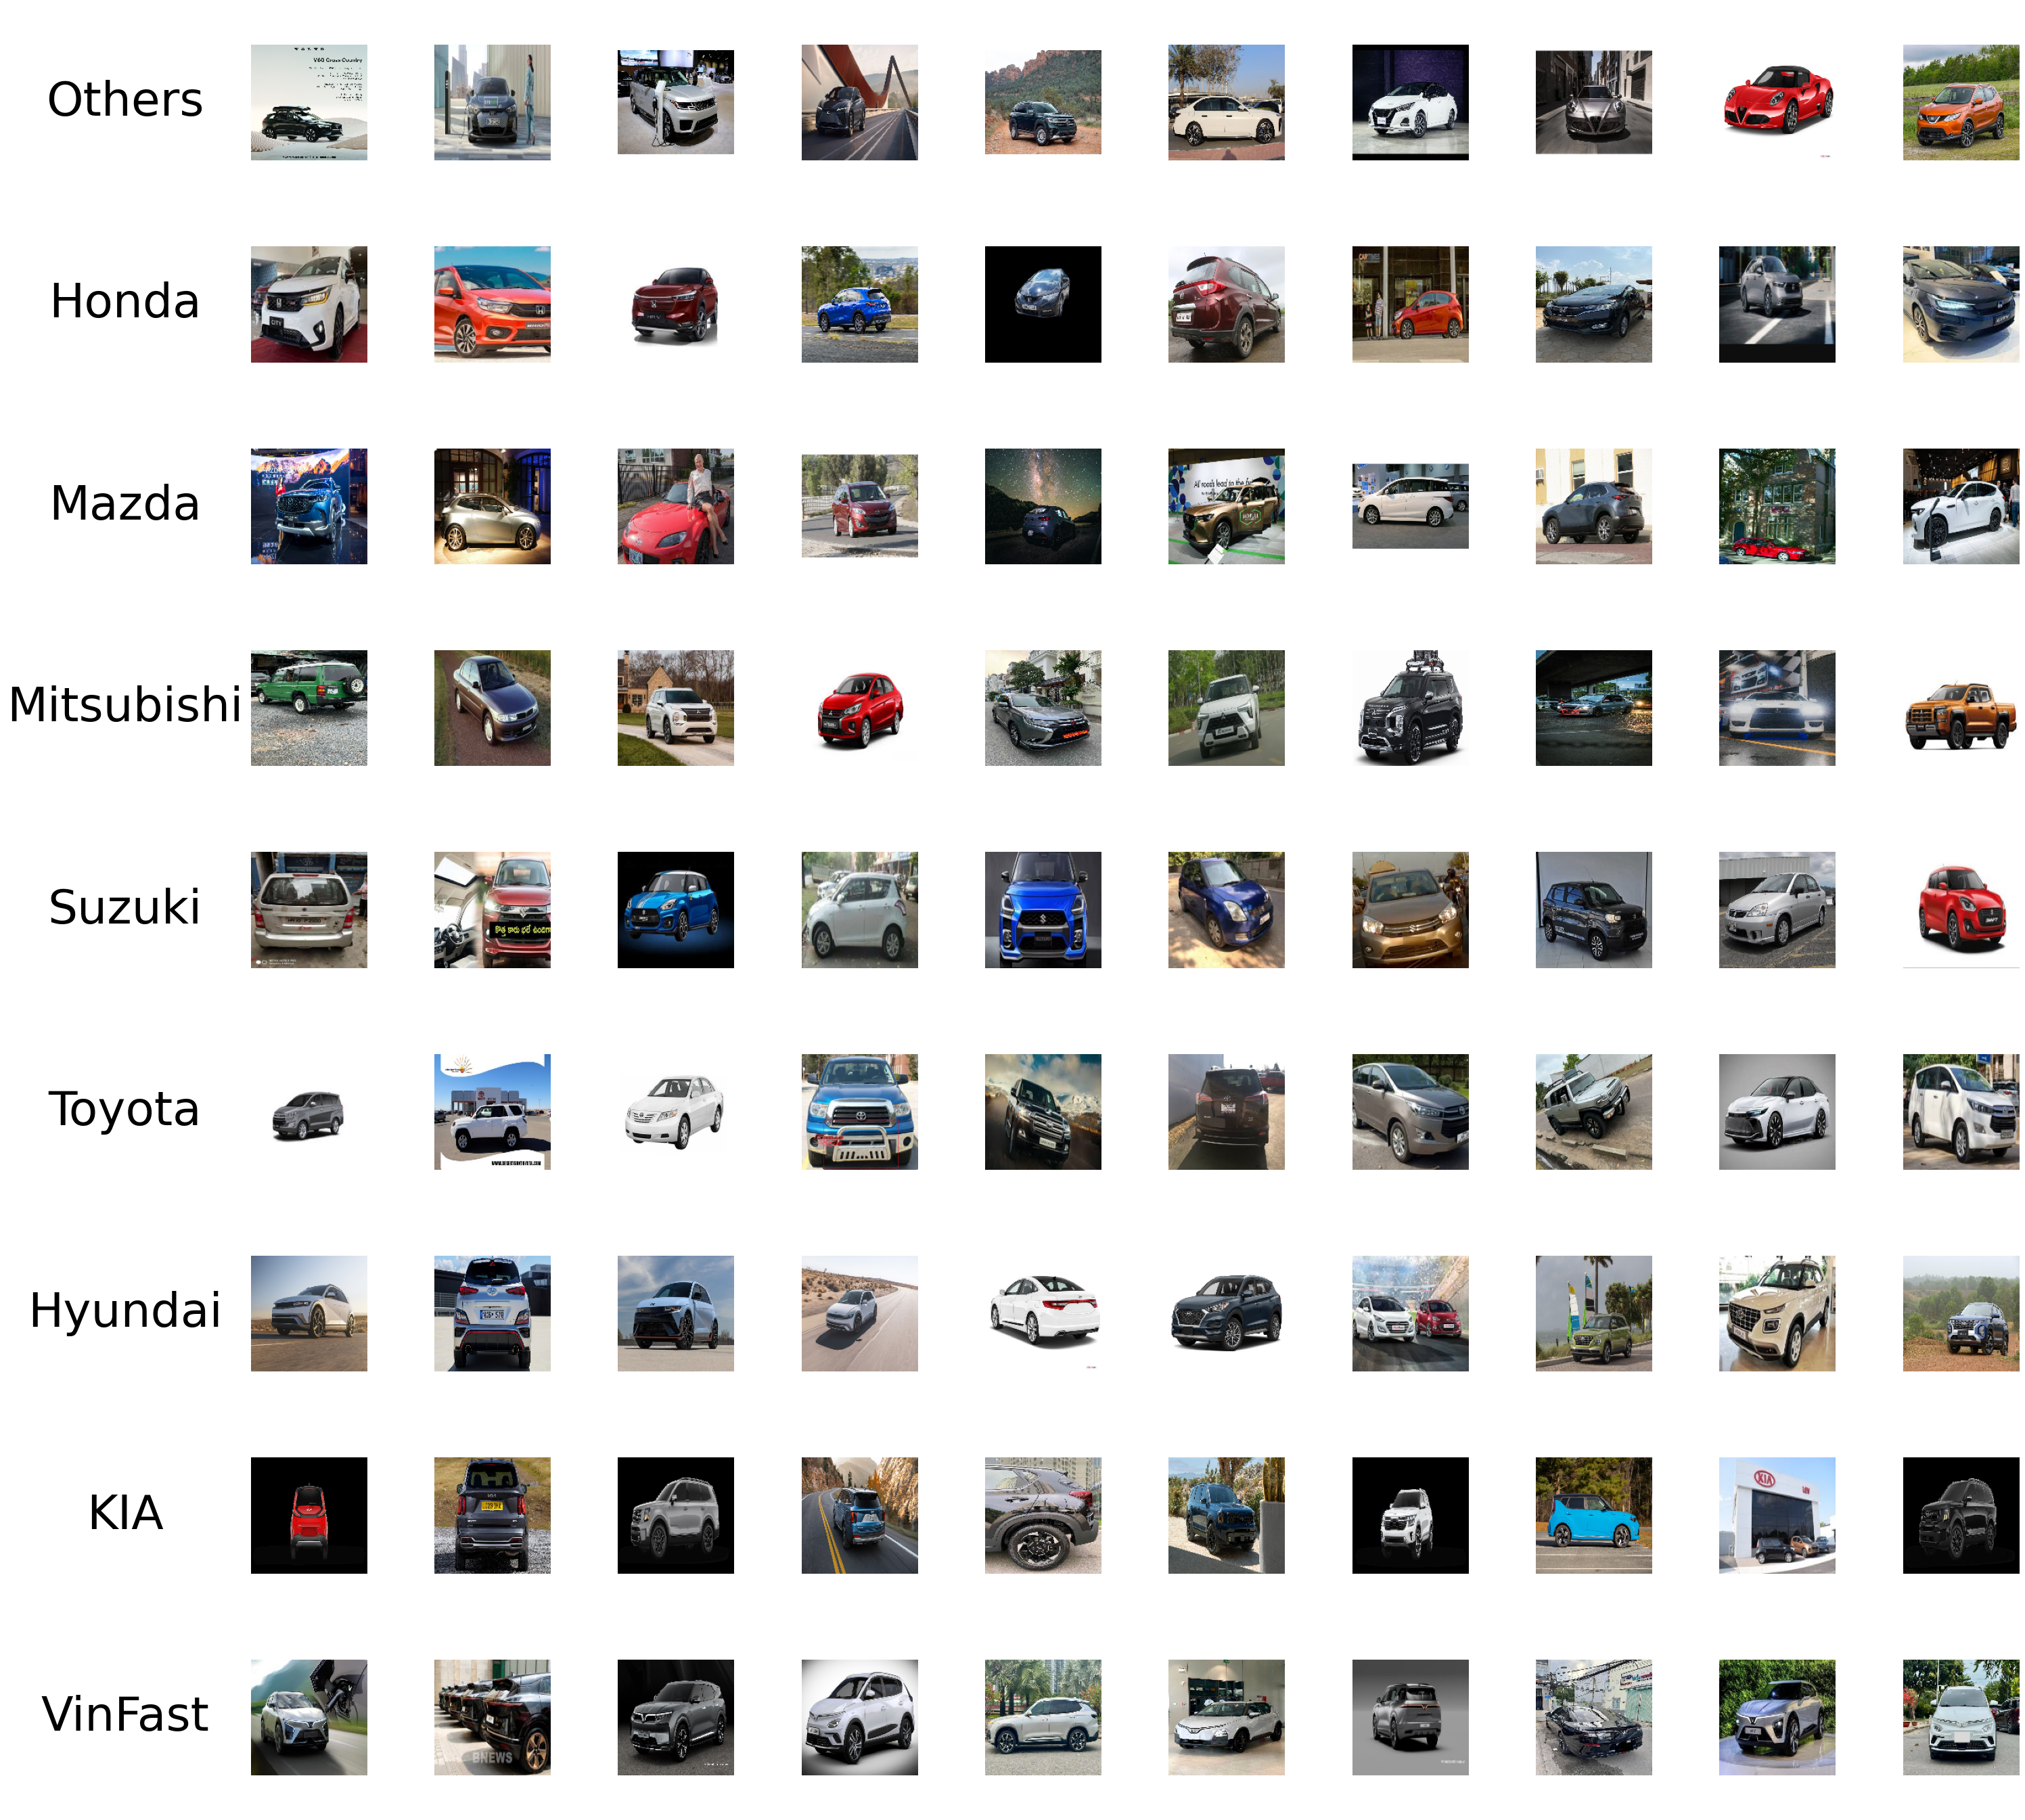

In [8]:
create_image_collage('/kaggle/input/car-brand/CarDataset.csv', data_path)

# Feature Extraction

In [11]:
# Place the model on GPU (TensorFlow will automatically use GPU if available)
with tf.device('/GPU:0'):  # Ensure to use GPU if available
    base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

<ipython-input-11-2e600bc49f35>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


In [21]:
def get_features_vector(img, model):
    """
    Extract features from a single image using the provided model and transformations.

    Args:
        img (numpy.ndarray): Input image.
        model (Model): Pre-trained feature extractor model.
        transform (albumentations.Compose): Augmentation pipeline.

    Returns:
        numpy.ndarray: Flattened feature vector.
    """
    # Apply transformations
    resized_img = cv2.resize(img, (224, 224)) 
    
    # Preprocess input for the model
    resized_img = np.expand_dims(resized_img, axis=0)  # Add batch dimension
    resized_img = preprocess_input(resized_img)

    # Predict features
    image_feature = model.predict(resized_img, verbose=0)
    return image_feature.flatten()  # Flatten feature vector

In [27]:
fold = pd.read_csv(f'/kaggle/input/car-brand/CarDataset.csv')
fold.columns = ['ImagePath', 'CategoryID']

In [28]:
image_paths = fold['ImagePath'].tolist()  # List of image paths
labels = fold['CategoryID'].tolist()  # Corresponding labels

# Initialize lists to store features and labels
X_train = []
y_train = []

# Correct total images calculation
total_images = len(image_paths)  # Number of images in the dataset

# Progress bar for feature extraction
with tqdm(total=total_images, desc="Extracting Features") as pbar:
    for i, image_path in enumerate(image_paths):
        try:
            img_path = os.path.join(data_path, image_path)
            
            # Check if the image exists and is valid
            if os.path.exists(img_path):
                img = cv2.imread(img_path, cv2.IMREAD_COLOR)  # Read image
            else:
                print(f"Image not found: {img_path}")
                continue
        except Exception as e:
            print(f"Error reading image {image_path}: {e}")
            continue
        
        # If image is successfully loaded, extract features
        if img is not None:
            features = get_features_vector(img, base_model)
            if features is not None:
                X_train.append(features)
                y_train.append(labels[i])
        
        pbar.update(1)  # Update progress bar

# Convert to NumPy arrays for compatibility with machine learning models
X_train = np.array(X_train)
y_train = np.array(y_train)

# Save extracted features and labels to .npy files
np.save('/kaggle/working/x_train_fold.npy', X_train)
np.save('/kaggle/working/y_train_fold.npy', y_train)

print("Feature extraction and saving complete!")

Extracting Features:   0%|          | 102/35290 [00:43<4:07:49,  2.37it/s]


KeyboardInterrupt: 

# Run all split

In [51]:
categories = {'Others': 0, 'Honda': 1, 'Mazda': 2, 'Mitsubishi': 3, 'Suzuki': 4, 'Toyota': 5, 'Hyundai': 6, 'KIA': 7, 'VinFast': 8}
data_path = '/kaggle/input/car-brand/Public/Public'
num_class = 9

In [7]:
def plot_training_history(history, curSplit):
    # Plot loss function
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Function Split {curSplit}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy Split {curSplit}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Hiển thị biểu đồ
    plt.show()

Train split 1


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,257 (3.13 MB)

 Trainable params: 821,257 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

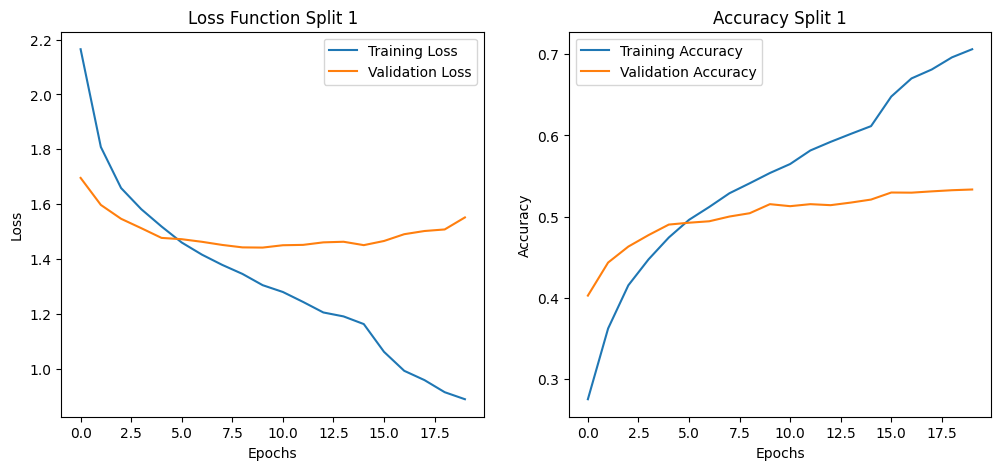

177/177 - 0s - 2ms/step - accuracy: 0.5335 - loss: 1.5515
Validation accuracy of Split 1: 0.5334750413894653
Train split 2


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,257 (3.13 MB)

 Trainable params: 821,257 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

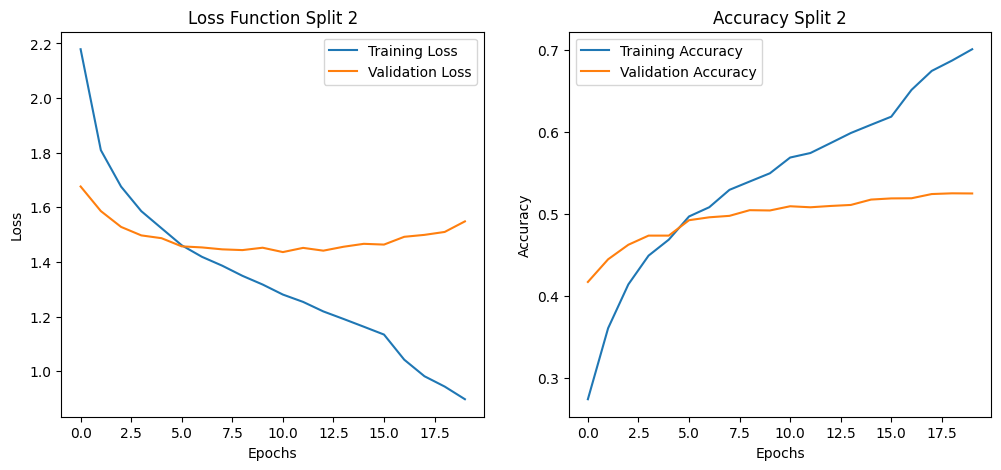

177/177 - 0s - 2ms/step - accuracy: 0.5246 - loss: 1.5484
Validation accuracy of Split 2: 0.5246192216873169
Train split 3


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_39 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_40 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,257 (3.13 MB)

 Trainable params: 821,257 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

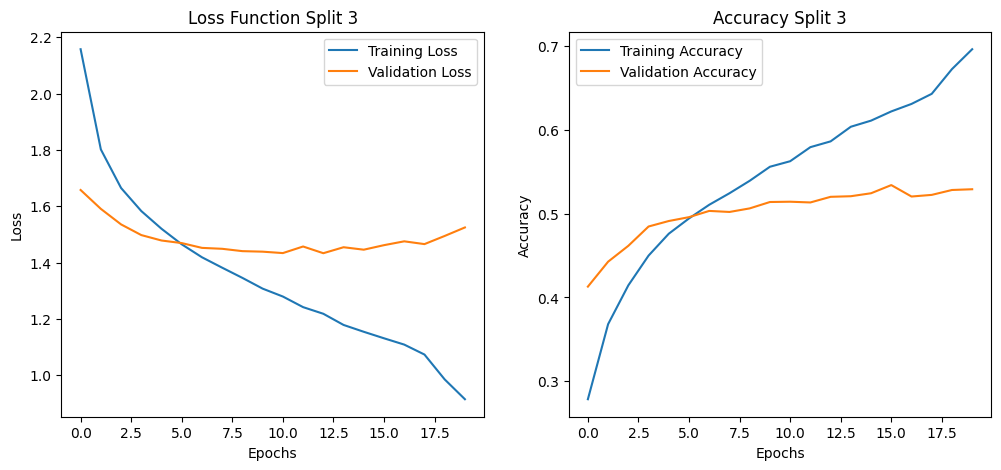

177/177 - 0s - 2ms/step - accuracy: 0.5290 - loss: 1.5249
Validation accuracy of Split 3: 0.5290471315383911
Train split 4


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_42 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_43 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_44 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,257 (3.13 MB)

 Trainable params: 821,257 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

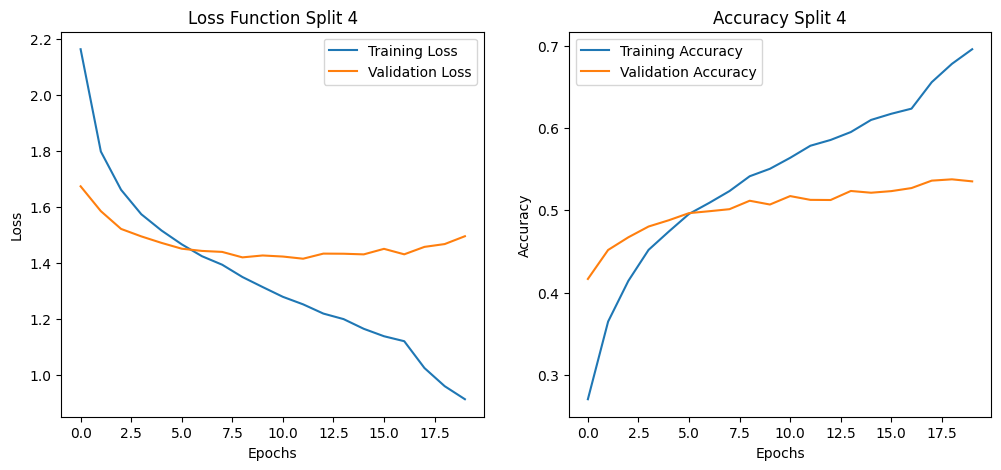

177/177 - 0s - 2ms/step - accuracy: 0.5352 - loss: 1.4951
Validation accuracy of Split 4: 0.5351638793945312
Train split 5


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_45 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_46 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,257 (3.13 MB)

 Trainable params: 821,257 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

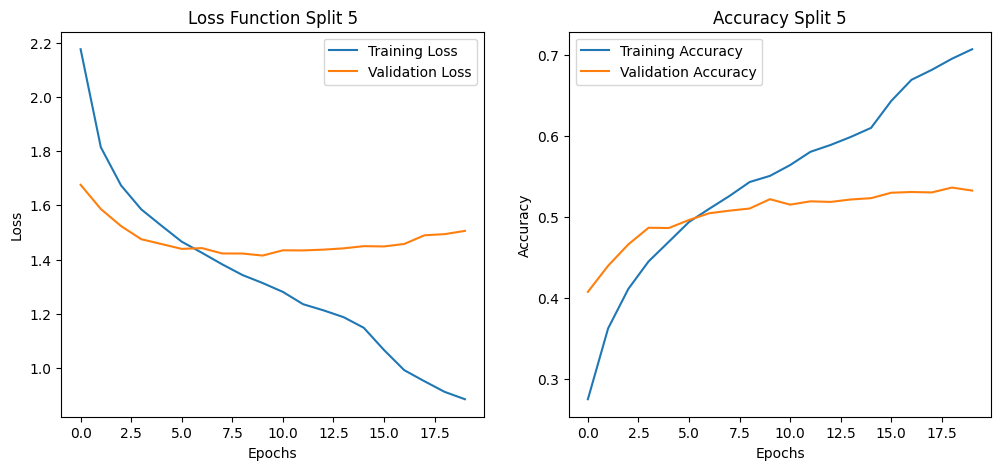

177/177 - 0s - 2ms/step - accuracy: 0.5327 - loss: 1.5057
Validation accuracy of Split 5: 0.532683789730072


In [13]:
X_train = np.load('/kaggle/input/feature/x_train_fold.npy')
y_train = np.load('/kaggle/input/feature/y_train_fold.npy')

k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

histories = []

for curSplit, (train_index, val_index) in enumerate(kf.split(X_train, y_train), 1):
    try:
        print(f'Train split {curSplit}')

        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        y_train_fold = to_categorical(y_train_fold, num_classes = 9)
        y_val_fold = to_categorical(y_val_fold, num_classes=9)

        model = Sequential()
        model.add(Input(shape=(X_train_fold.shape[1],)))
        model.add(Dense(512, activation='tanh'))
        model.add(Dropout(0.5))
        model.add(Dense(256, activation='tanh'))
        model.add(Dropout(0.5))
        model.add(Dense(128, activation='relu'))
        model.add(Dropout(0.5))
        model.add(Dense(9, activation='softmax'))

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        model.summary()

        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
        model_path = f"/content/drive/MyDrive/Competition3/best_model_{curSplit}.keras"
        checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, save_weights_only=False, mode='min')

        history = model.fit(
            X_train_fold,
            y_train_fold, 
            validation_data = (X_val_fold, y_val_fold),
            epochs=20,
            batch_size=64,
            verbose=0,
            callbacks=[reduce_lr, checkpoint]
        )

        # Store the training history
        histories.append(history)

        # Plot training history
        plot_training_history(history, curSplit)

        # Evaluate the model on the validation data (because X_test, y_test are not used for KFold)
        val_loss, val_acc = model.evaluate(X_val_fold, y_val_fold, verbose=2)
        print(f"Validation accuracy of Split {curSplit}: {val_acc}")

    except Exception as e:
        print(f"Error processing Split {curSplit}: {e}")

# Combine yolo

In [5]:
yolo_model = YOLO('yolov5s.pt') 

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



100%|██████████| 17.7M/17.7M [00:00<00:00, 40.8MB/s]


In [26]:
import logging

# Disable Ultralytics YOLO logging
logging.getLogger('ultralytics').setLevel(logging.CRITICAL)

def detect_and_crop_car(img, model):
    """
    Detect cars in an image using YOLO and crop the detected region.

    Args:
        img (numpy.ndarray): Input image.
        model (YOLO): Pre-trained YOLO model.

    Returns:
        numpy.ndarray: Cropped image containing the detected car or None if no car detected.
    """
    # Perform detection
    results = model(img)

    # Extract raw predictions from results
    detections = results[0].boxes  # Access bounding box predictions

    # Filter detections for the 'car' class (check your YOLO model's class IDs)
    car_detections = [box for box in detections if int(box.cls) == 2]  # '2' is the COCO ID for 'car'

    if len(car_detections) == 0:
        return None

    # Use the first detected car bounding box
    box = car_detections[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0])  # Extract bounding box coordinates

    # Crop the detected car region
    cropped_img = img[y1:y2, x1:x2]
    return cropped_img


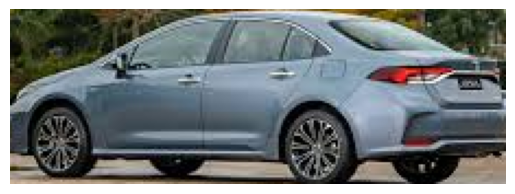

In [33]:
img_path = '/kaggle/input/car-brand/Public/Public/Toyota/21520930-21522924.Toyota.21-.png'
img = cv2.imread(img_path)

# Detect and crop the car from the image
cropped_car = detect_and_crop_car(img, yolo_model)

# If a car is detected, display the cropped image
if cropped_car is not None:
    plt.imshow(cv2.cvtColor(cropped_car, cv2.COLOR_BGR2RGB))
    plt.axis('off')  # Turn off axis
    plt.show()
else:
    print("No car detected in the image.")

In [27]:
def get_features_vector(img, model):
    """
    Extract features from a single image using the provided model.

    Args:
        img (numpy.ndarray): Input image.
        model (Model): Pre-trained feature extractor model.

    Returns:
        numpy.ndarray: Flattened feature vector.
    """
    # Resize the cropped image to the model's input size
    resized_img = cv2.resize(img, (224, 224))

    # Preprocess input for the model
    transformed_img = np.expand_dims(resized_img, axis=0)  # Add batch dimension
    transformed_img = preprocess_input(transformed_img)

    # Predict features
    image_feature = model.predict(transformed_img, verbose=0)
    return image_feature.flatten()  # Flatten feature vector

In [28]:
# Load dataset
fold = pd.read_csv(f'/kaggle/input/car-brand/CarDataset.csv')
fold.columns = ['ImagePath', 'CategoryID']

image_paths = fold['ImagePath'].tolist()  # List of image paths
labels = fold['CategoryID'].tolist()  # Corresponding labels

# Initialize lists to store features and labels
X_train = []
y_train = []

# Correct total images calculation
total_images = len(image_paths)

# Progress bar for feature extraction
with tqdm(total=total_images, desc="Extracting Features") as pbar:
    for i, image_path in enumerate(image_paths):
        try:
            img_path = os.path.join(data_path, image_path)

            # Check if the image exists
            if os.path.exists(img_path):
                img = cv2.imread(img_path, cv2.IMREAD_COLOR)  # Read image
            else:
                print(f"Image not found: {img_path}")
                continue
        except Exception as e:
            print(f"Error reading image {image_path}: {e}")
            continue

        # Detect and crop the car region
        if img is not None:
            cropped_img = detect_and_crop_car(img, yolo_model)
            if cropped_img is not None:
                # Extract features from the cropped image
                features = get_features_vector(cropped_img, base_model)
                X_train.append(features)  # Append features to the list
                y_train.append(labels[i])  # Append corresponding label

        pbar.update(1)  # Update progress bar

# Convert to NumPy arrays for compatibility with machine learning models
X_train = np.array(X_train)
y_train = np.array(y_train)

# Save extracted features and labels to .npy files
np.save('/kaggle/working/x_yolo_train_fold.npy', X_train)
np.save('/kaggle/working/y_yolo_train_fold.npy', y_train)

print("Feature extraction and saving complete!")

Extracting Features: 100%|██████████| 35290/35290 [46:10<00:00, 12.74it/s]  


Feature extraction and saving complete!


In [29]:
def plot_training_history(history, curSplit):
    # Plot loss function
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Function Split {curSplit}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy Split {curSplit}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Hiển thị biểu đồ
    plt.show()

Train split 1


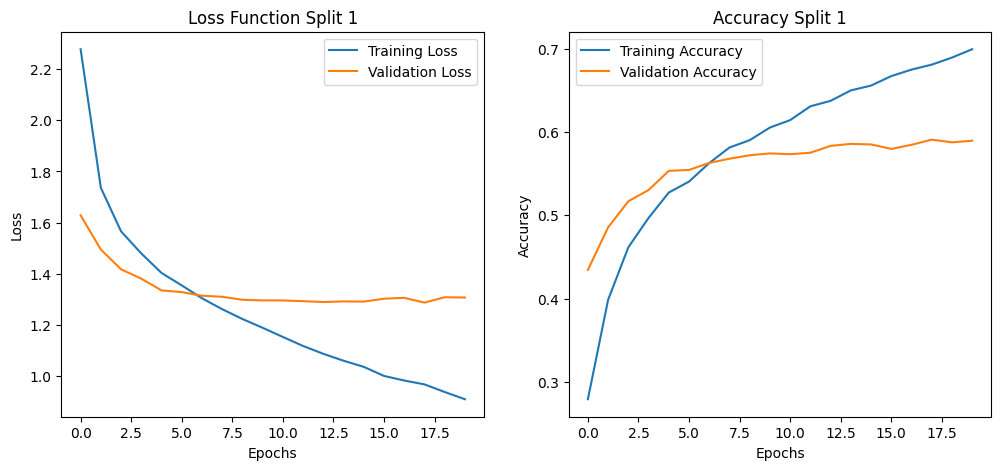

197/197 - 1s - 3ms/step - accuracy: 0.5897 - loss: 1.3069
Validation accuracy of Split 1: 0.589702844619751
Train split 2


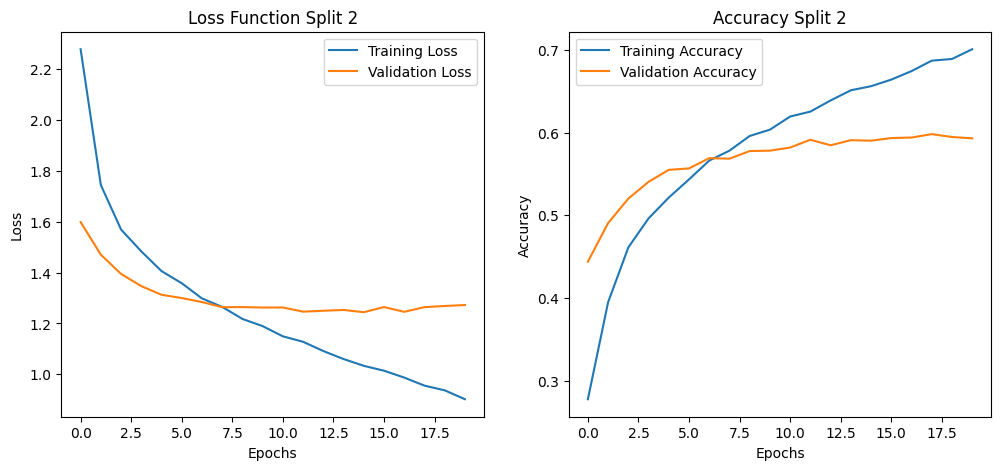

197/197 - 0s - 2ms/step - accuracy: 0.5932 - loss: 1.2723
Validation accuracy of Split 2: 0.5931987762451172
Train split 3


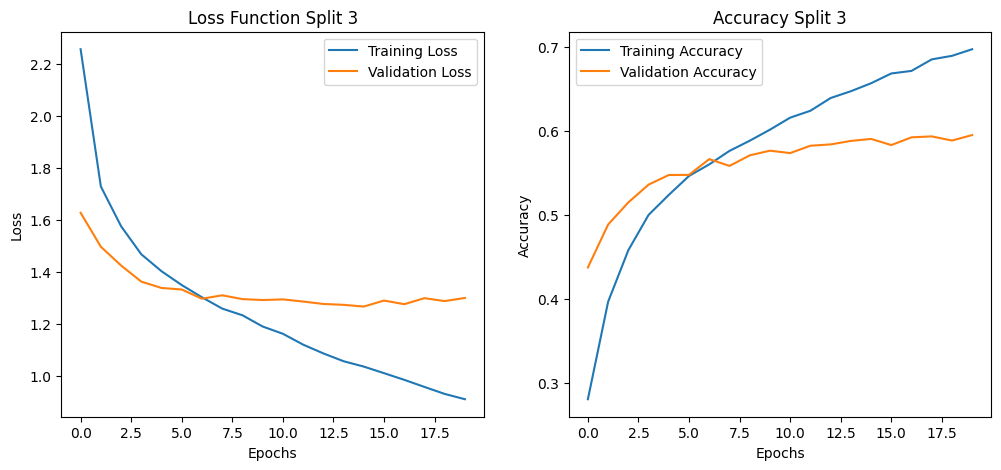

197/197 - 0s - 2ms/step - accuracy: 0.5952 - loss: 1.3008
Validation accuracy of Split 3: 0.59520024061203
Train split 4


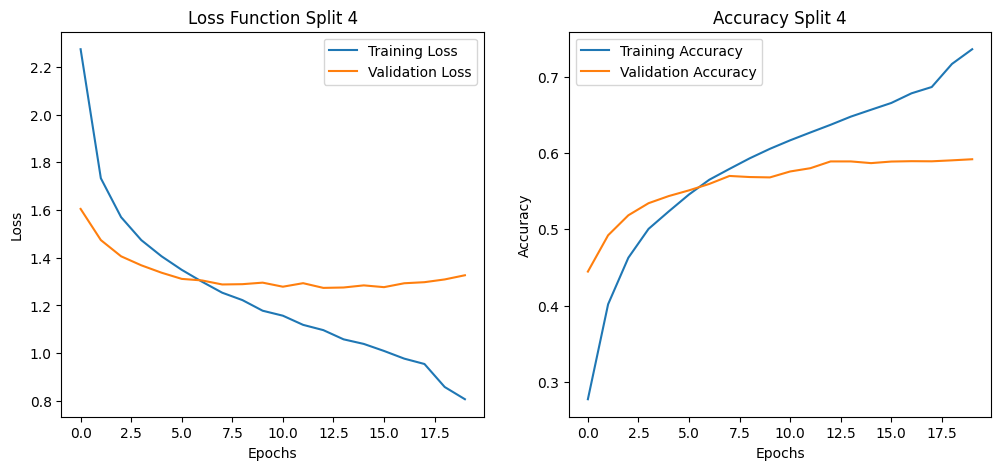

197/197 - 0s - 2ms/step - accuracy: 0.5920 - loss: 1.3267
Validation accuracy of Split 4: 0.592021644115448
Train split 5


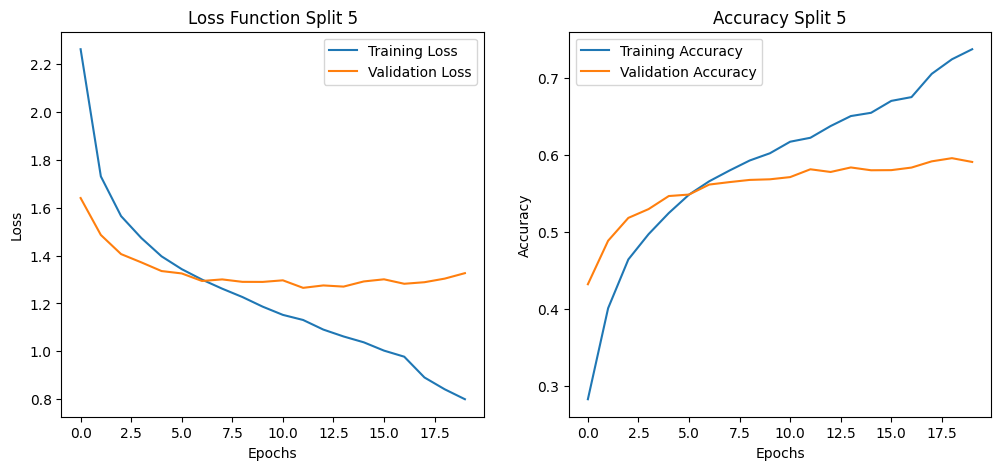

197/197 - 0s - 2ms/step - accuracy: 0.5909 - loss: 1.3265
Validation accuracy of Split 5: 0.5909090638160706


In [8]:
X_train = np.load('/kaggle/input/feature/x_yolo_train_fold.npy')
y_train = np.load('/kaggle/input/feature/y_yolo_train_fold.npy')

k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

histories = []

for curSplit, (train_index, val_index) in enumerate(kf.split(X_train, y_train), 1):
    try:
        print(f'Train split {curSplit}')

        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        y_train_fold = to_categorical(y_train_fold, num_classes = 9)
        y_val_fold = to_categorical(y_val_fold, num_classes=9)

        model = Sequential()
        model.add(Input(shape=(X_train_fold.shape[1],)))
        model.add(Dense(512, activation='tanh'))
        model.add(BatchNormalization())
        model.add(Dropout(0.5))
        model.add(Dense(256, activation='tanh'))
        model.add(BatchNormalization())
        model.add(Dropout(0.5))
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.5))
        model.add(Dense(9, activation='softmax'))

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
        model_path = f"/kaggle/working/best_model_{curSplit}.keras"
        checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, save_weights_only=False, mode='min')

        history = model.fit(
            X_train_fold,
            y_train_fold, 
            validation_data = (X_val_fold, y_val_fold),
            epochs=20,
            batch_size=64,
            verbose=0,
            callbacks=[reduce_lr, checkpoint]
        )

        # Store the training history
        histories.append(history)

        # Plot training history
        plot_training_history(history, curSplit)

        # Evaluate the model on the validation data (because X_test, y_test are not used for KFold)
        val_loss, val_acc = model.evaluate(X_val_fold, y_val_fold, verbose=2)
        print(f"Validation accuracy of Split {curSplit}: {val_acc}")

    except Exception as e:
        print(f"Error processing Split {curSplit}: {e}")